# Flood → Solar · M0 input data · 02 — DEM, geometry & depth context

**Peril:** Flood (riverine) · **Layer:** M0 (raw evidence) · method-neutral

**Goal of this notebook:** meet the *site-side* of the flood coupling at the two assets locked in
[`01`](01_site_screen_and_geometry.ipynb) — the **ground elevation** (3DEP DEM), the **footprint geometry**, and
the **FEMA flood-zone context** — then field-dictionary every layer and preview the coupling structure.

**Why this is the asset side of coupling.** Flood is *site-conditioned* (A21): the loss-driving quantity is
**depth-at-asset = water-surface-elevation(event) − ground-elevation(asset)**. This notebook nails the
**ground-elevation** half (real, from public DEM). The **water-surface / depth** half is the hazard input from
Fathom RP grids — **deferred** (JD-FL-2, external-data-gated) — so it's left as an explicit empty slot, not faked.

> **Two deferred swap-ins, two separate slots** (kept honest):
> 1. **Real footprint polygon** → the boundary *seam* below tries enriched-registry → OSM → **circle fallback**.
>    For these sites OSM has no polygon, so both resolve to a **capacity-radius circle** now; the enriched/EIA
>    `powerplants_enriched_v2` polygon swaps in later via the loader (DD-W5 pattern).
> 2. **Depth-at-return-period** → Fathom RP grids, a *different* loader (the hazard side). Not in this notebook.
>
> Plan: [`m0_input_data.md`](../../../docs/plans/flood/m0_input_data.md) · Decisions: [`decisions.md`](../../../docs/plans/flood/decisions.md).

In [1]:
import io, json, math, time, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import requests
from shapely.geometry import Point, shape
import geopandas as gpd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"

# --- tiny HTTP file-cache: memoize JSON responses → deterministic, flaky-endpoint-robust re-runs ---
import hashlib
_CACHE = OUT / "raw" / "http_cache"; _CACHE.mkdir(parents=True, exist_ok=True)
def cget(url, params=None, post=False, timeout=40):
    key = hashlib.md5((("P" if post else "G") + url + json.dumps(params, sort_keys=True, default=str)).encode()).hexdigest()
    f = _CACHE / (key + ".json")
    if f.exists():
        return json.loads(f.read_text())
    r = requests.post(url, data=params, timeout=timeout) if post else requests.get(url, params=params, timeout=timeout)
    j = r.json(); f.write_text(json.dumps(j)); return j
# ---------------------------------------------------------------------------------------------------

sites = pd.DataFrame(json.loads((OUT / "flood_m0_sites.json").read_text())["sites"])
print("sites locked in 01:")
print(sites[["role", "name", "eia", "state", "county", "lat", "lon", "solar_mw", "zone", "footprint_r_m"]].to_string(index=False))

sites locked in 01:
                role                  name   eia state    county       lat         lon  solar_mw zone  footprint_r_m
baseline (low-flood)  Hayhurst Texas Solar 66880    TX Culberson 31.815992 -104.085297      24.8 NONE            392
proving (high-flood) Elizabeth Solar Plant 66111    LA     Allen 30.819810  -92.971755     142.8    X            940


## 1 · Footprint geometry — the boundary seam (enriched → OSM → circle)

`load_boundary()` is the **seam** that keeps the polygon swap a one-place change (modular-from-day-one). It tries,
in order: the **enriched registry** (EIA-crosswalked polygons, external-data-gated) → **OSM** `power=plant` (public) →
**capacity-radius circle** fallback. Each site records its `geometry_source` so the basis is always auditable.

In [2]:
ENRICHED = ROOT / "renewablesinfo_org" / "data" / "dimensions" / "boundary" / "powerplants_enriched_v2.parquet"
_enr = pd.read_parquet(ENRICHED, columns=["eia_id", "geometry"]) if ENRICHED.exists() else None


def from_enriched(eia):
    if _enr is None:
        return None
    sub = _enr[_enr["eia_id"].astype(str) == str(eia)]
    if not len(sub):
        return None
    from shapely import wkb
    return wkb.loads(sub.iloc[0]["geometry"])


OVERPASS_MIRRORS = [
    "https://maps.mail.ru/osm/tools/overpass/api/interpreter",   # reachable here; main mirrors often blocked
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]


def from_osm(lat, lon, r_m=3000):
    q = (f'[out:json][timeout:30];('
         f'way["power"="plant"](around:{r_m},{lat},{lon});'
         f'relation["power"="plant"](around:{r_m},{lat},{lon});'
         f'way["plant:source"="solar"](around:{r_m},{lat},{lon}););out geom;')
    for ep in OVERPASS_MIRRORS:
        try:
            els = cget(ep, {"data": q}, post=True).get("elements", [])
            best = None
            for e in els:
                g = e.get("geometry")
                if g and len(g) >= 4:
                    poly = shape({"type": "Polygon", "coordinates": [[(p["lon"], p["lat"]) for p in g]]})
                    if best is None or poly.area > best.area:   # largest = the plant boundary, not a sub-feature
                        best = poly
            return best   # may be None (no polygon at this site)
        except Exception:
            continue
    return None


def circle(lat, lon, r_m):
    # buffer in equal-area (EPSG:5070), return in lon/lat (EPSG:4326)
    pt = gpd.GeoSeries([Point(lon, lat)], crs=4326).to_crs(5070)
    return pt.buffer(r_m).to_crs(4326).iloc[0]


def load_boundary(row):
    geom = from_enriched(row["eia"])
    if geom is not None:
        return geom, "enriched"
    geom = from_osm(row["lat"], row["lon"])
    if geom is not None:
        return geom, "osm"
    return circle(row["lat"], row["lon"], row["footprint_r_m"]), "circle"


geoms, srcs, areas = [], [], []
for _, row in sites.iterrows():
    g, s = load_boundary(row)
    a_km2 = gpd.GeoSeries([g], crs=4326).to_crs(5070).area.iloc[0] / 1e6
    geoms.append(g); srcs.append(s); areas.append(a_km2)
    print(f"  {row['name']:28s} → {s:9s} footprint  ({a_km2:.3f} km²)")
sites["geometry_source"] = srcs
sites["footprint_km2"] = np.round(areas, 3)
sites["boundary_wkt"] = [g.wkt for g in geoms]   # persist geometry → M1 samples depth over the real footprint
gsites = gpd.GeoDataFrame(sites, geometry=geoms, crs=4326)

  Hayhurst Texas Solar         → osm       footprint  (0.735 km²)


  Elizabeth Solar Plant        → osm       footprint  (3.911 km²)


## 2 · Ground elevation — 3DEP DEM (the asset susceptibility half of coupling)

Public USGS **3DEP** elevation, sampled across each footprint via the ImageServer `getSamples` op (no raster
download). We report the **elevation distribution** — this is the surface the flood water-level will later be
differenced against (`depth = water_surface − ground_elev`).

In [3]:
DEM_URL = "https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/getSamples"


def dem_samples(lat, lon, r_m, n=200):
    dlat = r_m / 111_320.0
    dlon = r_m / (111_320.0 * math.cos(math.radians(lat)))
    env = {"xmin": lon - dlon, "ymin": lat - dlat, "xmax": lon + dlon, "ymax": lat + dlat,
           "spatialReference": {"wkid": 4326}}
    p = {"geometry": json.dumps(env), "geometryType": "esriGeometryEnvelope", "sampleCount": n,
         "returnFirstValueOnly": "false", "f": "json"}
    r = cget(DEM_URL, p)
    return np.array([float(s["value"]) for s in r.get("samples", []) if s.get("value") not in (None, "NoData")])


dem_rows = []
for _, row in sites.iterrows():
    v = dem_samples(row["lat"], row["lon"], row["footprint_r_m"])
    dem_rows.append({"elev_min_m": v.min(), "elev_mean_m": v.mean(), "elev_max_m": v.max(),
                     "elev_relief_m": np.ptp(v), "elev_std_m": v.std(), "dem_n": len(v)})
    print(f"  {row['name']:28s} elev {v.mean():6.1f} m (min {v.min():.1f} / max {v.max():.1f}, relief {np.ptp(v):.1f} m, n={len(v)})")
dem = pd.DataFrame(dem_rows).round(2)
sites = pd.concat([sites, dem], axis=1)

  Hayhurst Texas Solar         elev  970.0 m (min 963.2 / max 981.0, relief 17.8 m, n=585)


  Elizabeth Solar Plant        elev   42.8 m (min 35.5 / max 51.1, relief 15.5 m, n=806)


## 3 · FEMA flood-zone context (NFHL)

The regulatory flood label at each site: SFHA zone + (where determined) the Base Flood Elevation. Zone `A` is the
1%-annual floodplain *without* a computed BFE (approximate) — so depth there needs the Fathom grid, not FEMA.

In [4]:
NFHL = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28/query"


def fema_zone(lat, lon):
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "inSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE,ZONE_SUBTY,STATIC_BFE",
         "returnGeometry": "false", "f": "json"}
    try:
        fs = cget(NFHL, p).get("features", [])
        if not fs:
            return ("NONE", None, None)
        a = fs[0]["attributes"]
        bfe = a.get("STATIC_BFE")
        bfe = None if bfe in (None, -9999) else bfe
        return (a.get("FLD_ZONE"), a.get("ZONE_SUBTY"), bfe)
    except Exception as e:
        return ("ERR", str(e)[:30], None)


zrows = [dict(zip(["fld_zone", "zone_subty", "static_bfe"], fema_zone(r["lat"], r["lon"]))) for _, r in sites.iterrows()]
sites = pd.concat([sites, pd.DataFrame(zrows)], axis=1)
print(sites[["name", "fld_zone", "zone_subty", "static_bfe"]].to_string(index=False))

                 name fld_zone                   zone_subty static_bfe
 Hayhurst Texas Solar     NONE                          NaN       None
Elizabeth Solar Plant        X AREA OF MINIMAL FLOOD HAZARD       None


## 3b · Flood-zone map — FEMA NFHL around each site

The regulatory flood zones in each site's neighbourhood, with the asset footprint (red) overlaid. **SFHA** (blue —
A/AE/V…) is the 1%-annual floodplain. Elizabeth's footprint **straddles the SFHA** (zone X centroid, Zone A within
the polygon — BLE confirms depth); Hayhurst has **no mapped panels** (unmapped desert = the true-zero baseline).

  zone fetch error: ('Connection aborted.', ConnectionResetError(54, '


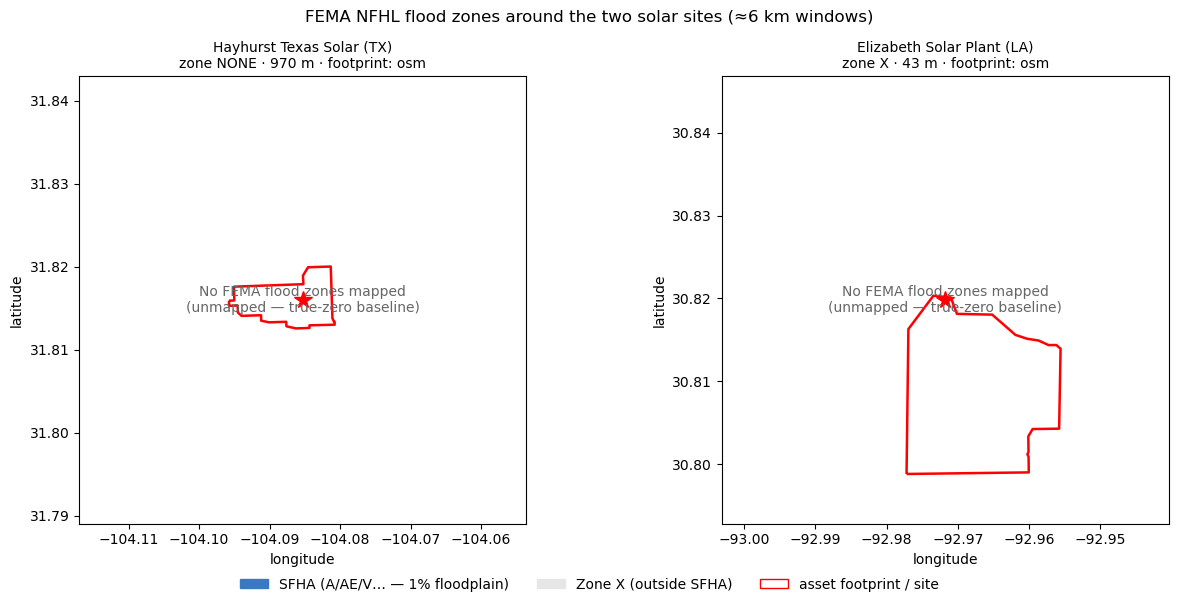

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m0_zone_map.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SFHA_Z = {"A", "AE", "AH", "AO", "AR", "A99", "V", "VE"}


def zone_color(z):
    if z in SFHA_Z:
        return "#3b78c3"   # SFHA — blue
    if z == "X":
        return "#e6e6e6"   # outside SFHA — light grey
    return "#b0b0b0"


def fetch_zone_polys(lat, lon, km=4):
    dlat = km * 1000 / 111_320.0
    dlon = km * 1000 / (111_320.0 * math.cos(math.radians(lat)))
    env = f"{lon-dlon},{lat-dlat},{lon+dlon},{lat+dlat}"
    p = {"geometry": env, "geometryType": "esriGeometryEnvelope", "inSR": 4326, "outSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE,ZONE_SUBTY",
         "returnGeometry": "true", "f": "geojson"}
    try:
        gj = cget(NFHL, p)
        if gj.get("features"):
            return gpd.GeoDataFrame.from_features(gj["features"], crs=4326)
    except Exception as e:
        print("  zone fetch error:", str(e)[:50])
    return gpd.GeoDataFrame({"FLD_ZONE": []}, geometry=[], crs=4326)


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (_, row) in zip(axes, sites.iterrows()):
    zg = fetch_zone_polys(row["lat"], row["lon"], km=4)
    if len(zg):
        zg.plot(ax=ax, color=zg["FLD_ZONE"].map(zone_color), edgecolor="white", linewidth=0.3)
    else:
        ax.text(0.5, 0.5, "No FEMA flood zones mapped\n(unmapped — true-zero baseline)",
                transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#666")
    gsites[gsites["eia"] == row["eia"]].boundary.plot(ax=ax, color="red", linewidth=1.8)
    ax.plot(row["lon"], row["lat"], marker="*", color="red", ms=13)
    ax.set_aspect(1 / math.cos(math.radians(row["lat"])))
    # pin both panels to the same fixed window around each site (zone polygons can be basin-sized)
    win_km = 3.0
    dla = win_km * 1000 / 111_320.0
    dlo = win_km * 1000 / (111_320.0 * math.cos(math.radians(row["lat"])))
    ax.set_xlim(row["lon"] - dlo, row["lon"] + dlo)
    ax.set_ylim(row["lat"] - dla, row["lat"] + dla)
    ax.set_title(f"{row['name']} ({row['state']})\nzone {row['fld_zone']} · {row['elev_mean_m']:.0f} m · footprint: {row['geometry_source']}", fontsize=10)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.ticklabel_format(useOffset=False, style="plain")

handles = [mpatches.Patch(color="#3b78c3", label="SFHA (A/AE/V… — 1% floodplain)"),
           mpatches.Patch(color="#e6e6e6", label="Zone X (outside SFHA)"),
           mpatches.Patch(facecolor="none", edgecolor="red", label="asset footprint / site")]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("FEMA NFHL flood zones around the two solar sites (≈6 km windows)", fontsize=12)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(OUT / "flood_m0_zone_map.png", dpi=120, bbox_inches="tight")
plt.show()
print("wrote:", OUT / "flood_m0_zone_map.png")

## 4 · Field dictionary (what each layer is, its datum/units, its base)

*Basics-spot-on:* every layer named with value · meaning · datum · units · source — so nothing is used blind.

In [6]:
field_dict = pd.DataFrame([
    ["ground_elevation", "3DEP DEM, sampled over footprint", "metres", "NAVD88 (vertical)", "USGS 3DEP ImageServer getSamples"],
    ["footprint", "asset boundary (or circle fallback)", "km² / polygon", "EPSG:4326 (area via 5070)", "enriched→OSM→circle seam"],
    ["fld_zone", "FEMA SFHA flood zone (A/AE/X/…)", "categorical", "NFHL", "FEMA NFHL layer 28"],
    ["static_bfe", "Base Flood Elevation (if determined)", "feet", "NAVD88", "FEMA NFHL (null in Zone A)"],
    ["depth_at_RP", "flood depth at return period — DEFERRED", "metres", "above ground", "Fathom RP grids (JD-FL-2, external-data-gated)"],
], columns=["field", "meaning", "units", "datum/ref", "source"])
print(field_dict.to_string(index=False))

           field                                 meaning         units                 datum/ref                                         source
ground_elevation        3DEP DEM, sampled over footprint        metres         NAVD88 (vertical)               USGS 3DEP ImageServer getSamples
       footprint     asset boundary (or circle fallback) km² / polygon EPSG:4326 (area via 5070)                       enriched→OSM→circle seam
        fld_zone         FEMA SFHA flood zone (A/AE/X/…)   categorical                      NFHL                             FEMA NFHL layer 28
      static_bfe    Base Flood Elevation (if determined)          feet                    NAVD88                     FEMA NFHL (null in Zone A)
     depth_at_RP flood depth at return period — DEFERRED        metres              above ground Fathom RP grids (JD-FL-2, external-data-gated)


## 5 · Coupling-structure preview — what depth will plug into

The M2 site-conditioned coupling is **`depth_at_asset = water_surface_elevation(event) − ground_elevation`**.
We now hold `ground_elevation` (the DEM distribution above); the `water_surface_elevation` per return period is
the **Fathom** input (deferred). The preview below shows the *structure* — the empty slot where depth enters — it
does **not** invent a depth.

In [7]:
for _, r in sites.iterrows():
    print(f"{r['name']} ({r['role']}):")
    print(f"   ground_elev ≈ {r['elev_mean_m']:.1f} m (NAVD88), footprint relief {r['elev_relief_m']:.1f} m, FEMA zone {r['fld_zone']}")
    print(f"   depth_at_asset = WSE(event) − ground_elev   ← WSE from Fathom RP grid [DEFERRED]")
    print(f"   → flat relief ({r['elev_relief_m']:.1f} m) means once WSE is known, the whole footprint floods to ~uniform depth\n"
          if r['elev_relief_m'] < 3 else
          f"   → {r['elev_relief_m']:.1f} m relief means depth will vary across the footprint (micro-topography matters)\n")

Hayhurst Texas Solar (baseline (low-flood)):
   ground_elev ≈ 970.0 m (NAVD88), footprint relief 17.8 m, FEMA zone NONE
   depth_at_asset = WSE(event) − ground_elev   ← WSE from Fathom RP grid [DEFERRED]
   → 17.8 m relief means depth will vary across the footprint (micro-topography matters)

Elizabeth Solar Plant (proving (high-flood)):
   ground_elev ≈ 42.8 m (NAVD88), footprint relief 15.5 m, FEMA zone X
   depth_at_asset = WSE(event) − ground_elev   ← WSE from Fathom RP grid [DEFERRED]
   → 15.5 m relief means depth will vary across the footprint (micro-topography matters)



## 6 · Known-answer checks (basics-spot-on)

- **Hayhurst** — high desert, dry: high elevation, **not** SFHA.
- **Elizabeth (high)** — Louisiana alluvial plain: **low elevation** and **flat** (floodplain signature). Its
  *centroid* is zone X, but the footprint straddles the SFHA and BLE confirms real flood depth (M1).

In [8]:
hay = sites[sites.eia == 66880].iloc[0]
bay = sites[sites.eia == 66111].iloc[0]   # Elizabeth Solar (high)
assert hay["elev_mean_m"] > 500 and hay["fld_zone"] not in {"A", "AE", "AH", "AO", "V", "VE"}, "Hayhurst KA fail"
assert bay["elev_mean_m"] < 100, "high-site KA fail (should be low-lying alluvial plain)"
assert bay["elev_relief_m"] < hay["elev_relief_m"], "expected the floodplain site flatter than the desert site"
print(f"✓ Hayhurst: {hay['elev_mean_m']:.0f} m, zone {hay['fld_zone']} (dry, high)")
print(f"✓ {bay['name']}: {bay['elev_mean_m']:.0f} m, zone {bay['fld_zone']}, relief {bay['elev_relief_m']:.1f} m (low, flat; SFHA in footprint, BLE depth in M1)")
print("✓ all known-answer checks pass — the low-vs-high contrast holds on real DEM + FEMA data.")

✓ Hayhurst: 970 m, zone NONE (dry, high)
✓ Elizabeth Solar Plant: 43 m, zone X, relief 15.5 m (low, flat; SFHA in footprint, BLE depth in M1)
✓ all known-answer checks pass — the low-vs-high contrast holds on real DEM + FEMA data.


## 7 · Persist the M0 context manifest

In [9]:
manifest = {
    "peril": "flood", "sub_peril": "riverine", "event_family_id": None, "layer": "M0",
    "deferred": {
        "depth_at_RP": "Fathom RP grids (hazard side; JD-FL-2, external-data-gated)",
        "real_footprint": "enriched-registry polygon (asset side; both sites on circle fallback now)",
    },
    "field_dictionary": field_dict.to_dict(orient="records"),
    "sites": json.loads(sites.drop(columns=[c for c in sites.columns if c == "geometry"], errors="ignore").to_json(orient="records")),
}
(OUT / "flood_m0_dem_context.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_m0_dem_context.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m0_dem_context.json


## Findings & what's next

- **Real, public, done:** ground elevation (3DEP DEM) and FEMA zone at both sites — a clean low-vs-high contrast
  (Hayhurst ~970 m / dry / not-SFHA vs Elizabeth ~43 m / flat / SFHA-in-footprint). The DEM is the *asset* half of the
  flood coupling, captured for real.
- **Two deferred swap-ins, both external-data-gated, both left as explicit empty slots:** the **Fathom depth grid** (hazard
  side) and the **enriched-registry polygon** (asset shape — both sites are on circle fallback; OSM had no
  footprint). The boundary *seam* means the polygon swap is a one-place change.
- **Honest limit:** with depth deferred, M0 establishes *where* and *how high the ground sits*, not yet *how deep
  the water gets* — that is the first thing M1 consumes once Fathom lands.
- **Next — M1 (catalog):** assemble the flood frequency profile (depth-at-return-period) on the Fathom RP grids,
  built as a **sub-peril-keyed catalog with a reserved `event_family_id`** (JD-FL-4) — riverine now, pluvial/
  coastal ready.